# Generative Adversarial Networks (GANs) in PyTorch

## Downloading and Exploring the Data

In [65]:
import torch 
from torchvision.transforms import ToTensor, Normalize, Compose
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn

In [8]:
mnist = MNIST(root = "/data",
              train=True,
              download=True,
              transform=Compose([ToTensor(), Normalize(mean=(0.5,), std=(0.5,))]))

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:23<00:00, 424kB/s]


Extracting /data\MNIST\raw\train-images-idx3-ubyte.gz to /data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 58.2kB/s]


Extracting /data\MNIST\raw\train-labels-idx1-ubyte.gz to /data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 896kB/s]


Extracting /data\MNIST\raw\t10k-images-idx3-ubyte.gz to /data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.51MB/s]

Extracting /data\MNIST\raw\t10k-labels-idx1-ubyte.gz to /data\MNIST\raw



In [10]:
img, label = mnist[0]
print("Label: ", label)
print(img[:, 10:15, 10:15])
torch.min(img), torch.max(img)

Label:  5
tensor([[[-0.9922,  0.2078,  0.9843, -0.2941, -1.0000],
         [-1.0000,  0.0902,  0.9843,  0.4902, -0.9843],
         [-1.0000, -0.9137,  0.4902,  0.9843, -0.4510],
         [-1.0000, -1.0000, -0.7255,  0.8902,  0.7647],
         [-1.0000, -1.0000, -1.0000, -0.3647,  0.8824]]])


(tensor(-1.), tensor(1.))

In [12]:
def denorms(x):
    out = (x+1)/2
    return out.clamp(0, 1)

Label:  5


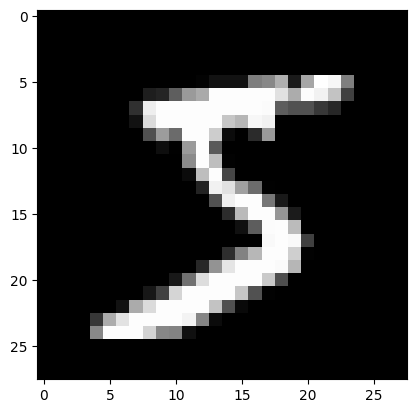

In [24]:
img_norm = denorms(img)
plt.imshow(img_norm[0], cmap="gray")
print("Label: ", label)

In [34]:
batch_size = 100

data_loader = DataLoader(mnist, batch_size, shuffle=True)

first batch
torch.Size([100, 1, 28, 28])
tensor([9, 1, 4, 4, 0, 4, 3, 4, 5, 4, 0, 3, 0, 9, 6, 3, 3, 3, 9, 5, 1, 9, 6, 0,
        6, 1, 2, 7, 4, 6, 7, 0, 7, 3, 1, 7, 1, 9, 0, 4, 6, 1, 9, 5, 9, 6, 9, 6,
        6, 8, 4, 4, 3, 1, 9, 7, 2, 3, 9, 1, 1, 0, 0, 3, 8, 5, 3, 2, 9, 8, 7, 1,
        9, 3, 0, 3, 1, 8, 7, 4, 5, 8, 1, 8, 0, 1, 4, 3, 0, 1, 4, 2, 2, 8, 7, 6,
        7, 0, 0, 2])


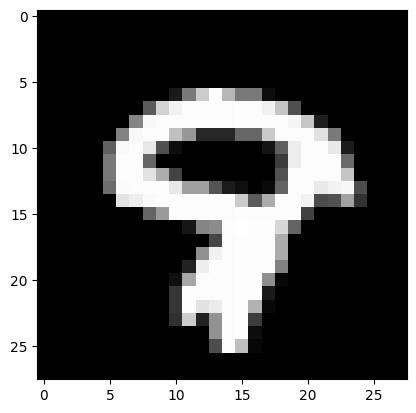

In [54]:
for img, label in data_loader:
    print("first batch")
    print(img.shape)
    print(label)
    plt.imshow(img[0][0], cmap="gray")
    break

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [58]:
device

device(type='cuda')

## Discrminator Network

In [71]:
image_size = 784
hidden_state = 256

In [73]:
D = nn.Sequential(
    nn.Linear(image_size, hidden_state),
    nn.LeakyReLU(0.2),
    nn.Linear(hidden_state, hidden_state),
    nn.LeakyReLU(0.2),
    nn.Linear(hidden_size, 1),
    nn.Sigmoid())

In [76]:
D.to(device)

Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): LeakyReLU(negative_slope=0.2)
  (4): Linear(in_features=256, out_features=1, bias=True)
  (5): Sigmoid()
)

In [78]:
latent_size = 64

In [82]:
G = nn.Sequential(
    nn.Linear(latent_size, hidden_state),
    nn.ReLU(),
    nn.Linear(hidden_state, hidden_state),
    nn.ReLU(),
    nn.Linear(hidden_state, image_size),
    nn.Tanh())

In [86]:
y = G(torch.randn(2, latent_size))
gen_imgs = denorms(y.reshape((-1, 28, 28)).detach())

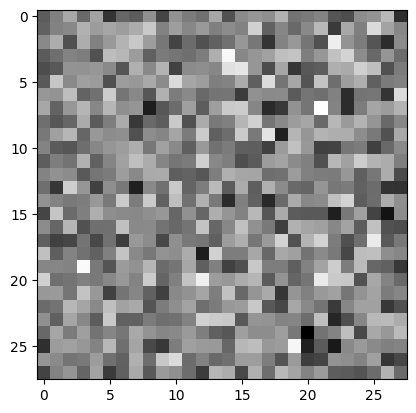

In [88]:
plt.imshow(gen_imgs[0], cmap="gray")

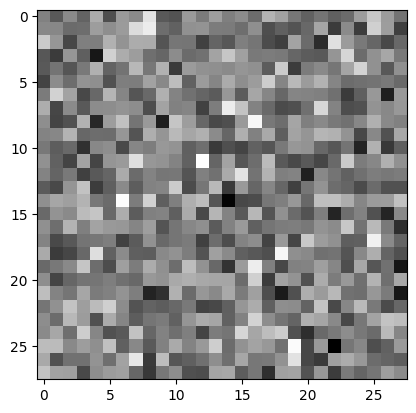

In [90]:
plt.imshow(gen_imgs[1], cmap="gray")

In [92]:
G.to(device)

Sequential(
  (0): Linear(in_features=64, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=784, bias=True)
  (5): Tanh()
)

## Discriminator Training

In [99]:
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002)
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002)

In [101]:
def reset_grad():
    d_optimizer.zero_grad()
    g_optimizer.zero_grad()

def train_discriminator(images):
    # Create the labels which are later used as input for the BCE loss
    real_labels = torch.ones(batch_size, 1).to(devices)
    fake_labels = torch.zeroes(batch_size, 1).to(device)

    #Loss for real images
    ouputs = D(images)
    d_loss_real = criterion(outputs, real_labels)
    real_score = output

    # Loss for the fake images
    z = torch.randn(batch_size, latent_size).to(device)
    fake_images = G(z)
    outputs = D(fake_images)
    d_loss_fake = criterion(outputs, fake_labels)
    fake_score = outputs

    #Combine losses
    d_loss = d_loss_real + d_loss_fake
    #Reset Gradients
    reset_grad()
    # Compute gradients
    d_loss.backward()
    # Adjust the parameters using backprop
    d_optimizer.step()

    return d_loss, real_score, fake_score

## Generator Training